# 🔍 Inference, Detection & Human Counting
### Task-03: Detection + Counting | Task-04: Tracking (Bonus)

Demonstrates the complete inference pipeline —
detection, counting, visualization, and ByteTrack tracking.

**Counting Logic:**
- Human = class_id 0 (pedestrian) + class_id 1 (people)
- Car = class_id 3 (car) + class_id 4 (van)

## 1. Load Trained Model
Load best.pt from models/weights/ for inference.

## 2. Detection & Counting on Drone Images
Run inference on random val images using src/detect.py.
Each image shows bounding boxes, labels, confidence scores,
and human/car count overlay in top-left corner.

✅ Model loaded: D:\drone-detection\models\weights\best.pt
✅ Saved → D:\drone-detection\outputs\images\detected_0000342_00393_d_0000244.jpg
✅ Saved → D:\drone-detection\outputs\images\detected_0000154_01201_d_0000001.jpg
✅ Saved → D:\drone-detection\outputs\images\detected_0000023_00868_d_0000010.jpg
✅ Saved → D:\drone-detection\outputs\images\detected_0000290_04001_d_0000867.jpg


C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_19620\1342351574.py:36: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_19620\1342351574.py:36: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_19620\1342351574.py:37: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("../assets/sample_images/inference_results.png",
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_19620\1342351574.py:37: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig("../assets/sample_images/inference_results.png",
C:\Python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

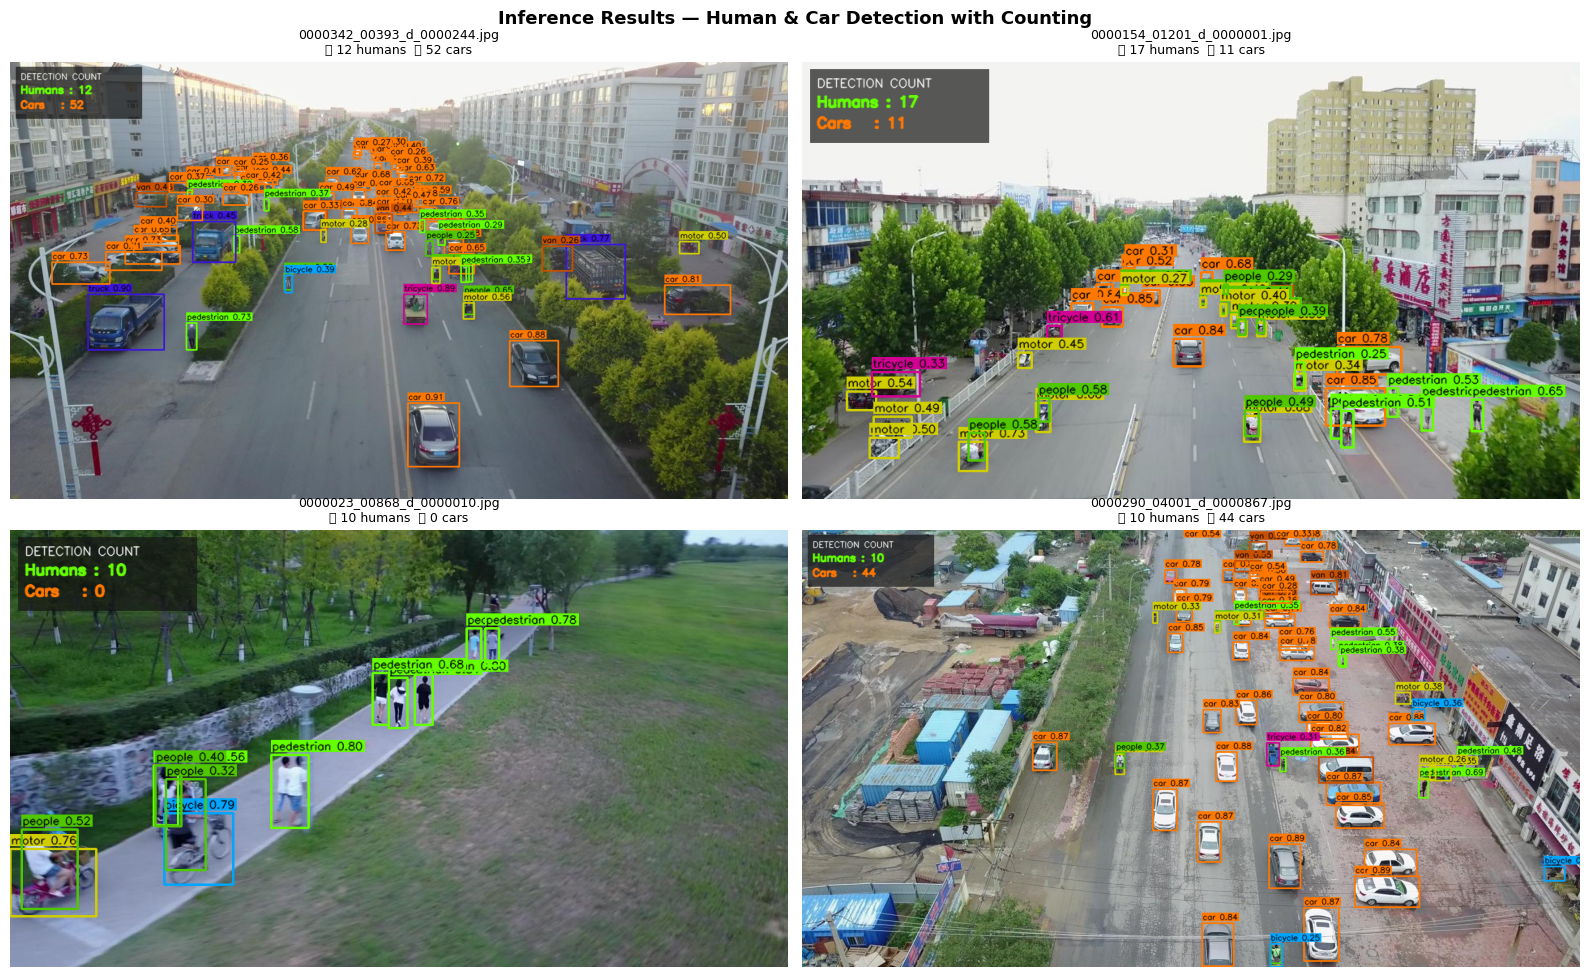

Saved → assets/sample_images/inference_results.png


In [1]:
import sys
sys.path.append("..")

import cv2
import random
import matplotlib.pyplot as plt
import importlib
import src.config as cfg
importlib.reload(cfg)
from src.config import *
from src.detect import load_model, process_image

model   = load_model()
val_dir = DATA_RAW_DIR / "VisDrone2019-DET-val" / IMAGES_FOLDER

# Test on 4 random images
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax in axes:
    img_path = random.choice(list(val_dir.glob("*.jpg")))
    out_path = OUTPUT_IMAGES_DIR / f"detected_{img_path.name}"

    annotated, humans, cars, detections = process_image(
        img_path, out_path, model
    )

    img_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"{img_path.name}\n👤 {humans} humans  🚗 {cars} cars",
                 fontsize=9)
    ax.axis("off")

plt.suptitle("Inference Results — Human & Car Detection with Counting",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_images/inference_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/inference_results.png")

## 3. ByteTrack Object Tracking — Bonus (Task-04)

ByteTrack assigns persistent IDs across consecutive frames.

| Feature | Detection | ByteTrack |
|---|---|---|
| Per-frame count | ✅ | ✅ |
| Persistent IDs | ❌ | ✅ |
| Movement trails | ❌ | ✅ |
| Unique count | ❌ | ✅ |

Activated with: `model.track(tracker='bytetrack.yaml', persist=True)`

✅ Tracked 10 images → D:\drone-detection\outputs\tracking
   Unique human IDs : 10
   Unique car IDs   : 27


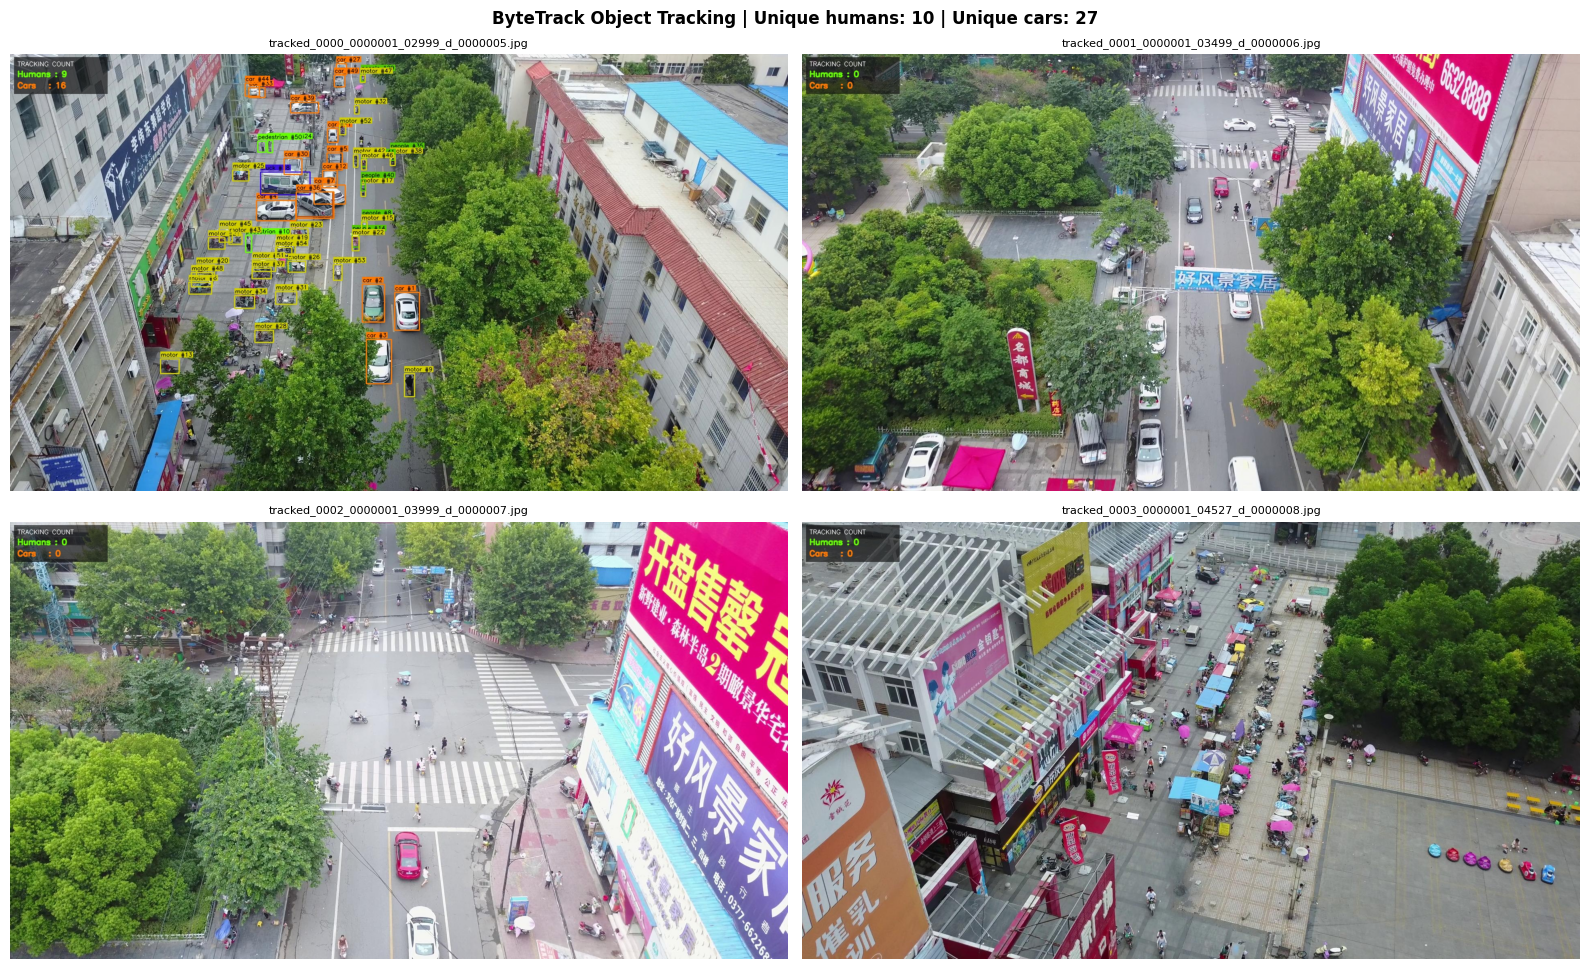

Saved → assets/sample_images/tracking_results.png


In [2]:
import sys
sys.path.append("..")

import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from ultralytics import YOLO
import importlib
import src.config as cfg
importlib.reload(cfg)
from src.config import *
from src.track import track_image_sequence, trajectory_history

model   = YOLO(str(WEIGHTS_DIR / "best.pt"))
val_dir = DATA_RAW_DIR / "VisDrone2019-DET-val" / IMAGES_FOLDER

# Use 10 consecutive images from same scene for realistic tracking


imgs = sorted(val_dir.glob("*.jpg"))[:10]




humans, cars = track_image_sequence(
    imgs,
    output_dir = OUTPUT_TRACKING_DIR,
    model      = model,
)

# Display first 4 tracked results
tracked_imgs = sorted(Path(OUTPUT_TRACKING_DIR).glob("tracked_*.jpg"))[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, tracked_imgs):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.suptitle(
    f"ByteTrack Object Tracking | Unique humans: {humans} | Unique cars: {cars}",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_images/tracking_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → assets/sample_images/tracking_results.png")

In [3]:
import sys
sys.path.append("..")
from ultralytics import YOLO
from src.config import *
from src.track import track_video

model = YOLO(str(WEIGHTS_DIR / "best.pt"))

frames, humans, cars = track_video(
    video_path  = r"D:\drone-detection\assets\drone_test.mp4",
    output_path = str(OUTPUT_TRACKING_DIR / "tracked_demo.mp4"),
    model       = model,
    conf        = 0.25,
    max_frames  = 300,   # first 10 seconds only
)

print(f"Unique humans tracked: {humans}")
print(f"Unique cars tracked  : {cars}")

Video: drone_test.mp4
  1280×720 @ 30fps | 9187 frames
  Frame 30/9187 | humans: 0, cars: 8 | unique human IDs: 0, unique car IDs: 9
  Frame 60/9187 | humans: 0, cars: 9 | unique human IDs: 0, unique car IDs: 12
  Frame 90/9187 | humans: 0, cars: 10 | unique human IDs: 0, unique car IDs: 18
  Frame 120/9187 | humans: 0, cars: 10 | unique human IDs: 0, unique car IDs: 20
  Frame 150/9187 | humans: 0, cars: 11 | unique human IDs: 0, unique car IDs: 24
  Frame 180/9187 | humans: 0, cars: 12 | unique human IDs: 0, unique car IDs: 30
  Frame 210/9187 | humans: 0, cars: 15 | unique human IDs: 0, unique car IDs: 35
  Frame 240/9187 | humans: 0, cars: 13 | unique human IDs: 0, unique car IDs: 37
  Frame 270/9187 | humans: 0, cars: 13 | unique human IDs: 0, unique car IDs: 38
  Frame 300/9187 | humans: 0, cars: 11 | unique human IDs: 0, unique car IDs: 39

✅ Tracking video saved → D:\drone-detection\outputs\tracking\tracked_demo.mp4

── Tracking Summary ──────────────────
  Frames processed    

## ✅ Inference Pipeline Complete

Full pipeline: Image → Letterbox → YOLOv8s → NMS → Count → Visualize

**Web Application:** Deployed as Flask app at localhost:5000
Upload any drone image/video for instant detection results.